In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pennylane torch scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 93.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.optim import Adam
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pennylane.qnn import TorchLayer


In [ ]:
csv_path = '/content/drive/MyDrive/dataset/autoencoder_regression_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)
data = df.to_numpy()

# Display shape
print("Shape:", df.shape)
df.head()

Shape: (98664, 18)


,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,-6.900868,-2.257141,0.207701,4.832452,3.164491,-3.497359,-0.399868,-3.593274,1.658348,17.176982,3327.875478,-3.855474,-3.844470,-8.889865,-4.018888,-3.195541,-7.868857,-5.895533
1,-1.916458,-3.192332,-2.223765,5.931571,4.592133,-4.370333,0.607382,-0.963816,0.258443,16.036432,2034.071133,-3.014919,-2.962217,-3.225697,-2.038615,-5.329029,-3.169883,-3.206833
2,-2.968401,-4.461657,0.615572,6.173611,3.366025,-3.686306,1.251608,-2.651082,0.503774,9.066010,1712.661454,-2.246068,-1.677456,-3.993484,-2.895214,-7.397882,-8.908273,-7.172669
3,-6.847833,-1.085600,1.159278,6.646182,2.965960,-3.345752,1.183463,-3.545845,0.562965,7.254639,3287.260930,-1.086659,-3.761693,-8.448541,-3.301345,-4.516020,-7.289866,-7.753208
4,-6.317009,-2.666278,0.357277,5.979415,3.764004,-3.740373,0.478526,-2.697041,0.745250,35.230361,2895.010899,-1.323324,-1.794849,-8.350682,-4.666140,-6.680365,-6.197769,-5.475105


In [ ]:

df.describe()

,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
count,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000
mean,0.432125,-3.457424,-3.516597,3.565911,4.389943,-3.945479,0.114160,-1.418761,1.060991,22.680367,1990.529089,-3.203587,-1.506352,-5.497066,-5.490777,-5.500600,-5.500026,-5.508865
std,3.234254,1.967700,3.186135,1.796521,1.560807,1.812092,2.572931,1.960795,0.542885,10.043365,866.480792,2.187283,1.445999,2.021719,2.020946,2.027659,2.023330,2.020505
min,-14.811619,-15.821565,-34.447407,-10.412514,-0.998671,-8.042172,-17.367699,-17.314592,0.100042,5.000412,500.059513,-6.999982,-3.999971,-8.999924,-8.999969,-8.999911,-8.999990,-8.999985
25%,-1.607159,-4.582289,-4.866113,2.445690,3.396904,-5.127968,-1.442510,-2.488036,0.593661,14.036827,1238.898762,-5.087822,-2.762471,-7.250021,-7.239419,-7.264763,-7.260083,-7.261356
50%,1.228101,-3.437524,-2.951968,3.444859,4.215981,-4.415377,0.642672,-1.233767,1.061147,22.724996,1986.033911,-3.215291,-1.504305,-5.488896,-5.485339,-5.499874,-5.502937,-5.508495
75%,2.808834,-2.111875,-1.699876,4.814338,5.243215,-3.260385,2.143631,-0.132477,1.531775,31.344526,2737.571477,-1.317402,-0.255494,-3.753459,-3.741738,-3.740803,-3.745523,-3.763974
max,8.470268,1.421151,3.338503,8.002897,16.989565,12.363155,5.335825,3.258902,1.999990,39.999593,3499.933503,0.599861,0.999957,-2.000011,-2.000260,-2.000041,-2.000107,-2.000021


In [ ]:
def prepare_data(df, target_col, test_size=0.2, val_size=0.2, random_state=42):
    """
    Prepares data for quantum-classical hybrid regression (torch tensors).

    Args:
        df (pd.DataFrame): Input dataframe.
        target_col (str): Column name of target variable.
        test_size (float): Fraction of test data.
        val_size (float): Fraction of validation data (from train split).
        random_state (int): Random seed.

    Returns:
        X_train, X_val, X_test (torch.Tensor): Classical input features.
        y_train, y_val, y_test (torch.Tensor): Targets.
    """
    X = df.iloc[:, :8].values.astype(np.float32)

    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)

    y = df[target_col].values.astype(np.float32).reshape(-1, 1)

    # Train-test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_norm, y, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=random_state
    )

    # Convert to torch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_val   = torch.tensor(X_val, dtype=torch.float32)
    X_test  = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_val   = torch.tensor(y_val, dtype=torch.float32)
    y_test  = torch.tensor(y_test, dtype=torch.float32)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1):
    """
    Builds the ablated quantum-classical hybrid model where the QNN branch
    is replaced by a zero-output module. Function signature and class names
    match the original so it can be swapped in place for comparisons.
    """
    class ZeroQNN(nn.Module):
        def __init__(self, out_dim):
            super().__init__()
            self.out_dim = out_dim

        def forward(self, x_quantum):
            batch = x_quantum.shape[0]
            return torch.zeros((batch, self.out_dim), device=x_quantum.device, dtype=x_quantum.dtype)

    class BalancedHybridModel(nn.Module):
        def __init__(self, qlayer, n_qubits, n_outputs):
            super().__init__()
            self.fc1 = nn.Linear(n_features, 64)
            self.bn1 = nn.BatchNorm1d(64)
            self.fc2 = nn.Linear(64, 32)
            self.bn2 = nn.BatchNorm1d(32)

            # qlayer argument replaced with a ZeroQNN so the branch outputs zeros of shape (batch, n_qubits)
            self.qnn = ZeroQNN(out_dim=n_qubits)
            self.fc_fuse1 = nn.Linear(32 + n_qubits, 32)
            self.fc_fuse2 = nn.Linear(32, n_outputs)

        def forward(self, x_classical, x_quantum):
            c = F.relu(self.bn1(self.fc1(x_classical)))
            c = F.relu(self.bn2(self.fc2(c)))
            q = self.qnn(x_quantum)
            x = torch.cat([c, q], dim=1)
            x = F.relu(self.fc_fuse1(x))
            out = self.fc_fuse2(x)
            return out

        def get_branch_outputs(self, x_classical, x_quantum):
            c = F.relu(self.bn1(self.fc1(x_classical)))
            c = F.relu(self.bn2(self.fc2(c)))
            q = self.qnn(x_quantum)
            fused = torch.cat([c, q], dim=1)
            return q, fused

    # keep qlayer argument for compatibility (not used)
    dummy_qlayer = None
    model = BalancedHybridModel(dummy_qlayer, n_qubits, n_outputs)
    return model


In [ ]:

def train_model(model,
                X_train, X_val, X_test,
                y_train, y_val, y_test,
                target_name,
                epochs=100, batch_size=32, lr=0.001, patience=20,
                save_dir="/content/drive/MyDrive/"):
    """
    Trains the BalancedHybridModel with early stopping and saves model per target.

    Args:
        model (nn.Module): Hybrid model instance.
        X_train, X_val, X_test (torch.Tensor): Input features.
        y_train, y_val, y_test (torch.Tensor): Targets.
        target_name (str): Name of the atmospheric parameter (used for save path).
        epochs (int): Maximum number of epochs.
        batch_size (int): Batch size.
        lr (float): Learning rate.
        patience (int): Early stopping patience.
        save_dir (str): Directory to save best model weights.

    Returns:
        model (nn.Module): Trained model with best weights loaded.
        history (dict): Training history with 'loss', 'val_loss', 'mae', 'val_mae'.
    """

    save_path = f"{save_dir}abl_best_{target_name}.pth"

    optimizer = Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    wait = 0
    history = {"loss": [], "val_loss": [], "mae": [], "val_mae": []}

    for epoch in range(epochs):
        model.train()
        idx = torch.randperm(X_train.size(0))
        batch_losses, batch_mae = [], []

        for i in range(0, X_train.size(0), batch_size):
            batch_idx = idx[i:i+batch_size]
            xb, yb = X_train[batch_idx], y_train[batch_idx]

            optimizer.zero_grad()
            preds = model(xb, xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            batch_mae.append(torch.mean(torch.abs(preds - yb)).item())

        # Training metrics
        train_loss = np.mean(batch_losses)
        train_mae = np.mean(batch_mae)

        # Validation metrics
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val, X_val)
            val_loss = loss_fn(val_preds, y_val).item()
            val_mae = torch.mean(torch.abs(val_preds - y_val)).item()

        # Save history
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train MSE: {train_loss:.4f}, Val MSE: {val_loss:.4f}, "
              f"Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))
    model.eval()

    return model, history


In [ ]:
def compute_metrics(model, X_test, y_test):
    """
    Computes RMSE, MAE, and R2 for a trained model on the test set.

    Args:
        model (nn.Module): Trained model.
        X_test (torch.Tensor): Test inputs.
        y_test (torch.Tensor): Test targets.

    Returns:
        metrics (dict): Dictionary with 'rmse', 'mae', 'r2'.
        y_pred (np.ndarray): Model predictions as numpy array.
    """
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test, X_test).numpy()

    metrics = {
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred)
    }

    print(f"\nTest Metrics:")
    print(f"RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f}, R²={metrics['r2']:.3f}")

    return metrics, y_pred

In [ ]:
def plot_training_and_results(history, model, X_test, y_test, target_name):
    """
    Plots training curves (MSE & MAE) and scatter plot of true vs predicted.

    Args:
        history (dict): Training history with keys 'loss', 'val_loss', 'mae', 'val_mae'.
        model (nn.Module): Trained model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): Test targets.
        target_name (str): Name of the target parameter (for titles).
    """
    import matplotlib.pyplot as plt
    model.eval()

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # MSE
    axes[0].plot(history['loss'], label='Train MSE')
    axes[0].plot(history['val_loss'], label='Val MSE')
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE")
    axes[0].set_title(f"MSE Curve ({target_name})")
    axes[0].legend()

    # MAE
    axes[1].plot(history['mae'], label='Train MAE')
    axes[1].plot(history['val_mae'], label='Val MAE')
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("MAE")
    axes[1].set_title(f"MAE Curve ({target_name})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n" * 5)

    # Scatter plot: True vs Predicted
    with torch.no_grad():
        y_pred = model(X_test, X_test).numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel(f"True {target_name}")
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"True vs Predicted ({target_name})")
    plt.show()

In [ ]:
def show_random_predictions(model, X_test, y_test, n_samples=20, target_name="Target"):
    """
    Displays predictions for a random subset of test samples.

    Args:
        model (nn.Module): Trained model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): Test targets.
        n_samples (int): Number of random samples to display.
        target_name (str): Name of the target parameter (for display).
    """
    model.eval()
    with torch.no_grad():
        idx = torch.randperm(X_test.size(0))[:n_samples]
        X_sample = X_test[idx]
        y_true_sample = y_test[idx]
        y_pred_sample = model(X_sample, X_sample).cpu().numpy()

    print(f"\n Predictions for {n_samples} Random Test Samples ({target_name}):")
    for i in range(n_samples):
        print(f"Sample {i+1}: True={y_true_sample[i].item():.4f}, Pred={y_pred_sample[i,0]:.4f}")

# **log_H2O**

In [ ]:
target = "log_H2O"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

#  Build the model
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)



In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=100, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")



Epoch 1/100, Train MSE: 1.7995, Val MSE: 0.8646, Train MAE: 0.9343, Val MAE: 0.7086
Epoch 2/100, Train MSE: 1.0190, Val MSE: 0.8593, Train MAE: 0.7661, Val MAE: 0.6922
Epoch 3/100, Train MSE: 0.9499, Val MSE: 0.8473, Train MAE: 0.7372, Val MAE: 0.6857
Epoch 4/100, Train MSE: 0.9051, Val MSE: 0.7544, Train MAE: 0.7167, Val MAE: 0.6538
Epoch 5/100, Train MSE: 0.8805, Val MSE: 0.7989, Train MAE: 0.7038, Val MAE: 0.6444
Epoch 6/100, Train MSE: 0.8605, Val MSE: 0.7810, Train MAE: 0.6928, Val MAE: 0.6361
Epoch 7/100, Train MSE: 0.8439, Val MSE: 0.6947, Train MAE: 0.6867, Val MAE: 0.6119
Epoch 8/100, Train MSE: 0.8352, Val MSE: 0.7915, Train MAE: 0.6828, Val MAE: 0.6435
Epoch 9/100, Train MSE: 0.8347, Val MSE: 0.7348, Train MAE: 0.6840, Val MAE: 0.6229
Epoch 10/100, Train MSE: 0.8197, Val MSE: 0.7576, Train MAE: 0.6757, Val MAE: 0.6232
Epoch 11/100, Train MSE: 0.8209, Val MSE: 0.6414, Train MAE: 0.6759, Val MAE: 0.5913
Epoch 12/100, Train MSE: 0.8087, Val MSE: 0.7092, Train MAE: 0.6707, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=0.798, MAE=0.589, R²=0.846


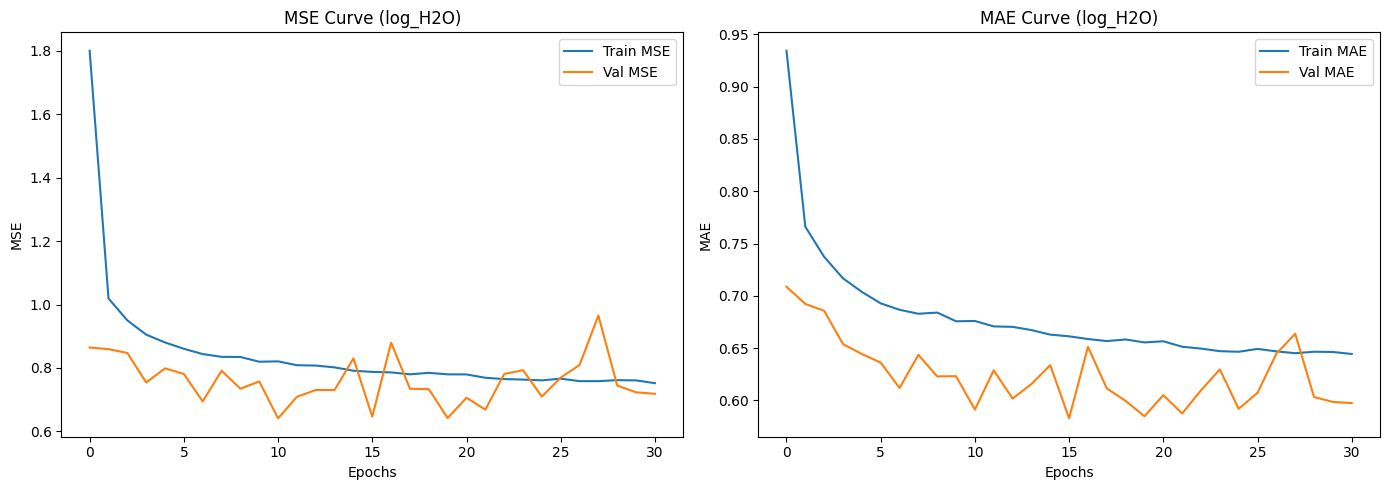

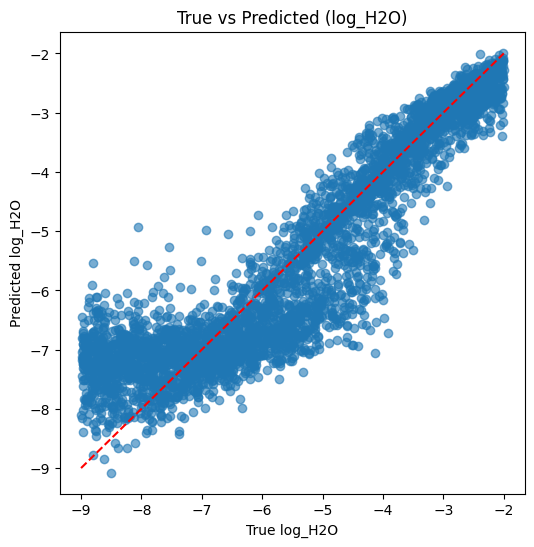

In [ ]:
#  Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_H2O):
Sample 1: True=-2.3119, Pred=-2.4582
Sample 2: True=-6.4126, Pred=-6.8288
Sample 3: True=-4.1247, Pred=-6.5388
Sample 4: True=-5.9485, Pred=-6.4286
Sample 5: True=-8.3069, Pred=-7.6967
Sample 6: True=-7.1226, Pred=-7.2530
Sample 7: True=-7.6536, Pred=-7.5255
Sample 8: True=-3.2783, Pred=-2.9867
Sample 9: True=-3.0322, Pred=-2.6708
Sample 10: True=-5.7039, Pred=-6.3904
Sample 11: True=-8.9667, Pred=-8.3828
Sample 12: True=-7.7579, Pred=-7.3099
Sample 13: True=-5.5613, Pred=-6.4201
Sample 14: True=-4.8862, Pred=-4.9932
Sample 15: True=-6.4491, Pred=-6.5676
Sample 16: True=-7.7997, Pred=-7.6041
Sample 17: True=-7.0696, Pred=-6.9350
Sample 18: True=-5.8075, Pred=-6.6670
Sample 19: True=-6.7264, Pred=-7.1010
Sample 20: True=-8.6545, Pred=-7.6051


# **log_CO2**

In [ ]:
#  target
target = "log_CO2"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)


In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=100, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/100, Train MSE: 1.1058, Val MSE: 0.3341, Train MAE: 0.6847, Val MAE: 0.4320
Epoch 2/100, Train MSE: 0.4541, Val MSE: 0.3457, Train MAE: 0.5185, Val MAE: 0.4328
Epoch 3/100, Train MSE: 0.3917, Val MSE: 0.3822, Train MAE: 0.4796, Val MAE: 0.4721
Epoch 4/100, Train MSE: 0.3648, Val MSE: 0.2627, Train MAE: 0.4619, Val MAE: 0.3835
Epoch 5/100, Train MSE: 0.3464, Val MSE: 0.2534, Train MAE: 0.4479, Val MAE: 0.3721
Epoch 6/100, Train MSE: 0.3360, Val MSE: 0.2725, Train MAE: 0.4408, Val MAE: 0.3880
Epoch 7/100, Train MSE: 0.3244, Val MSE: 0.2872, Train MAE: 0.4334, Val MAE: 0.3893
Epoch 8/100, Train MSE: 0.3139, Val MSE: 0.2661, Train MAE: 0.4253, Val MAE: 0.3853
Epoch 9/100, Train MSE: 0.3093, Val MSE: 0.2455, Train MAE: 0.4225, Val MAE: 0.3666
Epoch 10/100, Train MSE: 0.3097, Val MSE: 0.2543, Train MAE: 0.4223, Val MAE: 0.3699
Epoch 11/100, Train MSE: 0.3006, Val MSE: 0.2694, Train MAE: 0.4153, Val MAE: 0.3755
Epoch 12/100, Train MSE: 0.2997, Val MSE: 0.3650, Train MAE: 0.4145, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)



Test Metrics:
RMSE=0.479, MAE=0.357, R²=0.945


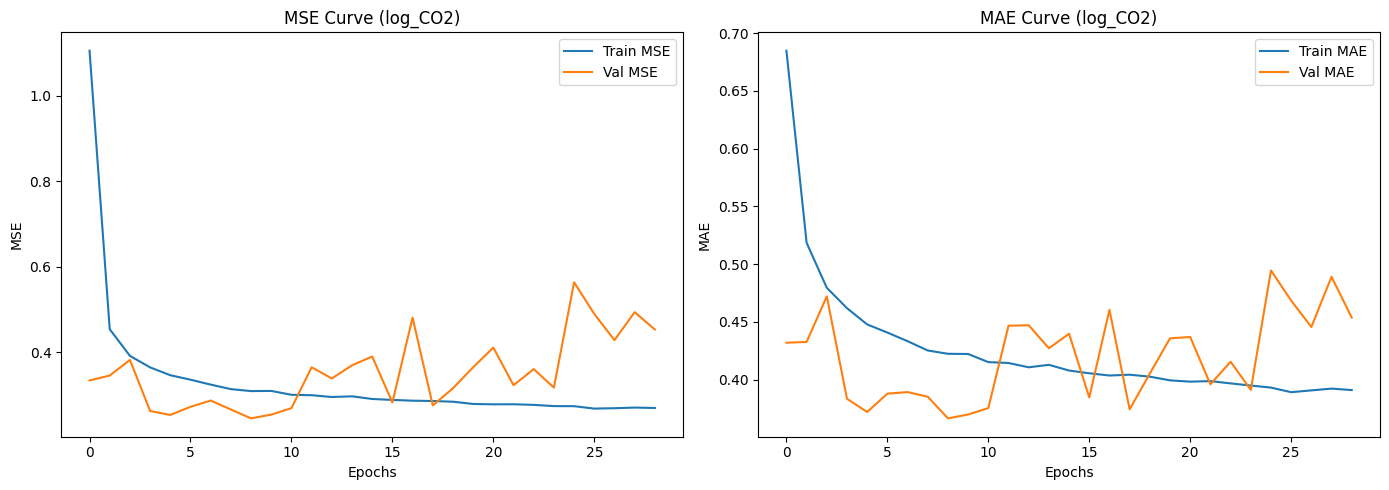

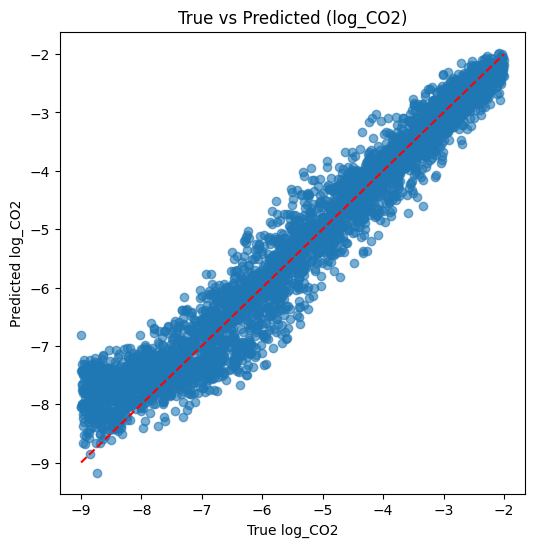

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)



In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_CO2):
Sample 1: True=-4.0390, Pred=-3.9595
Sample 2: True=-2.7520, Pred=-2.5841
Sample 3: True=-7.7403, Pred=-7.7760
Sample 4: True=-3.4200, Pred=-3.3574
Sample 5: True=-3.9557, Pred=-3.8188
Sample 6: True=-2.7950, Pred=-2.6374
Sample 7: True=-8.3118, Pred=-7.4050
Sample 8: True=-2.1675, Pred=-2.3458
Sample 9: True=-7.5303, Pred=-7.3569
Sample 10: True=-8.4124, Pred=-8.1549
Sample 11: True=-3.2825, Pred=-3.6845
Sample 12: True=-4.0467, Pred=-4.2167
Sample 13: True=-7.2560, Pred=-7.3878
Sample 14: True=-7.4439, Pred=-7.2343
Sample 15: True=-3.9636, Pred=-3.8293
Sample 16: True=-2.3110, Pred=-2.4589
Sample 17: True=-2.1943, Pred=-2.3493
Sample 18: True=-7.8016, Pred=-7.6961
Sample 19: True=-8.1964, Pred=-7.8320
Sample 20: True=-8.6883, Pred=-8.6702


# **log_CO**

In [ ]:
target = "log_CO"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)

In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=200, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/200, Train MSE: 3.5255, Val MSE: 2.5285, Train MAE: 1.4769, Val MAE: 1.2759
Epoch 2/200, Train MSE: 2.6274, Val MSE: 2.3332, Train MAE: 1.3099, Val MAE: 1.2319
Epoch 3/200, Train MSE: 2.5321, Val MSE: 2.2644, Train MAE: 1.2783, Val MAE: 1.1986
Epoch 4/200, Train MSE: 2.4460, Val MSE: 2.2250, Train MAE: 1.2499, Val MAE: 1.1830
Epoch 5/200, Train MSE: 2.4027, Val MSE: 2.1600, Train MAE: 1.2361, Val MAE: 1.1880
Epoch 6/200, Train MSE: 2.3728, Val MSE: 2.1288, Train MAE: 1.2253, Val MAE: 1.1599
Epoch 7/200, Train MSE: 2.3467, Val MSE: 2.0324, Train MAE: 1.2170, Val MAE: 1.1108
Epoch 8/200, Train MSE: 2.3277, Val MSE: 2.2756, Train MAE: 1.2113, Val MAE: 1.1644
Epoch 9/200, Train MSE: 2.3006, Val MSE: 2.1927, Train MAE: 1.2025, Val MAE: 1.1410
Epoch 10/200, Train MSE: 2.2796, Val MSE: 2.1413, Train MAE: 1.1942, Val MAE: 1.1318
Epoch 11/200, Train MSE: 2.2755, Val MSE: 2.2263, Train MAE: 1.1927, Val MAE: 1.1665
Epoch 12/200, Train MSE: 2.2734, Val MSE: 1.9910, Train MAE: 1.1927, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=1.332, MAE=1.032, R²=0.562


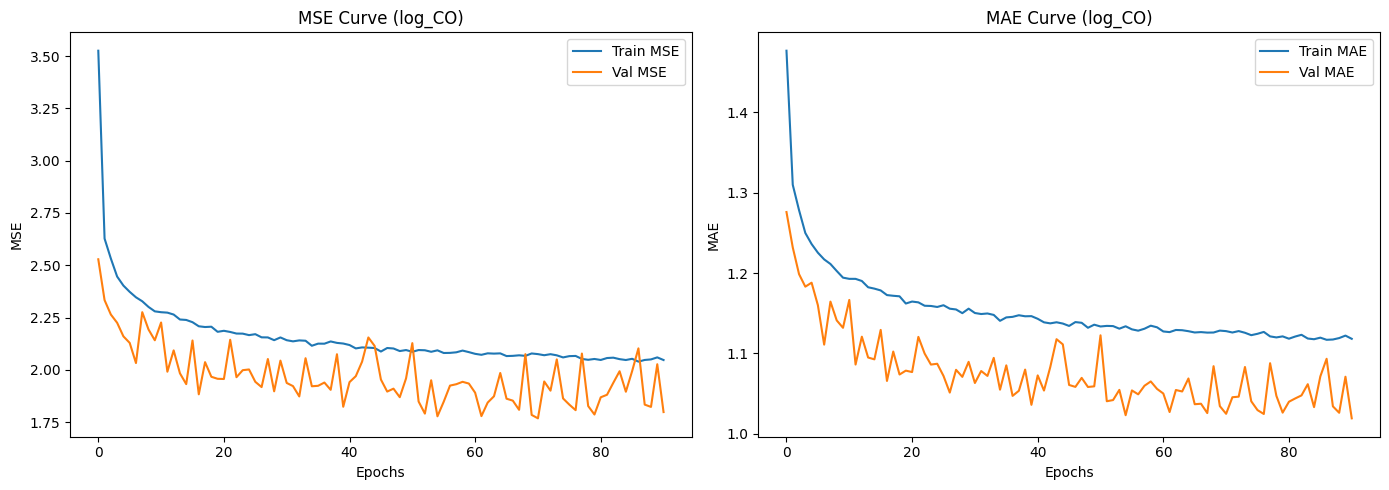

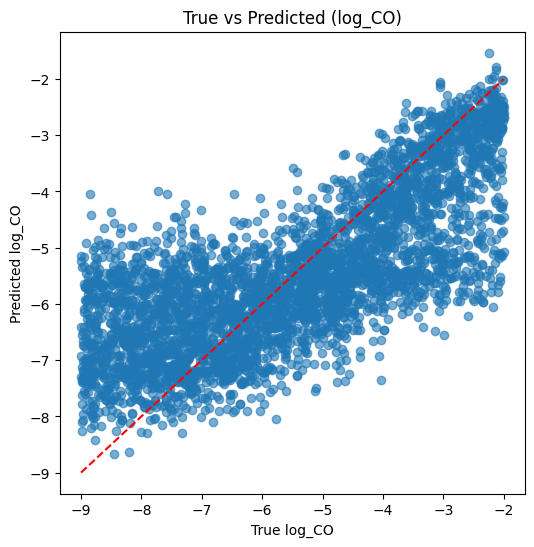

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_CO):
Sample 1: True=-8.3686, Pred=-6.5326
Sample 2: True=-4.7093, Pred=-7.1774
Sample 3: True=-7.0101, Pred=-5.5952
Sample 4: True=-4.2074, Pred=-5.8146
Sample 5: True=-3.8994, Pred=-3.6915
Sample 6: True=-5.9107, Pred=-7.1573
Sample 7: True=-5.7114, Pred=-6.2276
Sample 8: True=-8.2577, Pred=-6.3926
Sample 9: True=-4.6816, Pred=-5.0090
Sample 10: True=-8.3614, Pred=-5.9282
Sample 11: True=-3.7016, Pred=-3.7183
Sample 12: True=-7.1787, Pred=-6.3312
Sample 13: True=-3.5525, Pred=-3.2307
Sample 14: True=-8.5749, Pred=-6.7454
Sample 15: True=-3.6734, Pred=-5.6095
Sample 16: True=-7.3586, Pred=-5.3668
Sample 17: True=-6.6488, Pred=-5.6626
Sample 18: True=-3.6374, Pred=-5.4157
Sample 19: True=-7.1789, Pred=-7.5611
Sample 20: True=-6.6684, Pred=-6.1580


# **log_CH4**

In [ ]:
target = "log_CH4"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)

In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=200, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/200, Train MSE: 1.6446, Val MSE: 0.7810, Train MAE: 0.8650, Val MAE: 0.6649
Epoch 2/200, Train MSE: 0.8419, Val MSE: 0.6915, Train MAE: 0.6900, Val MAE: 0.6159
Epoch 3/200, Train MSE: 0.7803, Val MSE: 0.6815, Train MAE: 0.6629, Val MAE: 0.6150
Epoch 4/200, Train MSE: 0.7539, Val MSE: 0.7156, Train MAE: 0.6472, Val MAE: 0.6013
Epoch 5/200, Train MSE: 0.7404, Val MSE: 0.6919, Train MAE: 0.6398, Val MAE: 0.6023
Epoch 6/200, Train MSE: 0.7211, Val MSE: 0.6602, Train MAE: 0.6306, Val MAE: 0.5880
Epoch 7/200, Train MSE: 0.7165, Val MSE: 0.7021, Train MAE: 0.6265, Val MAE: 0.5876
Epoch 8/200, Train MSE: 0.7080, Val MSE: 0.6775, Train MAE: 0.6216, Val MAE: 0.5851
Epoch 9/200, Train MSE: 0.7019, Val MSE: 0.6801, Train MAE: 0.6185, Val MAE: 0.5797
Epoch 10/200, Train MSE: 0.6925, Val MSE: 0.6396, Train MAE: 0.6127, Val MAE: 0.5788
Epoch 11/200, Train MSE: 0.6906, Val MSE: 0.7151, Train MAE: 0.6123, Val MAE: 0.6070
Epoch 12/200, Train MSE: 0.6857, Val MSE: 0.5830, Train MAE: 0.6093, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=0.725, MAE=0.509, R²=0.871


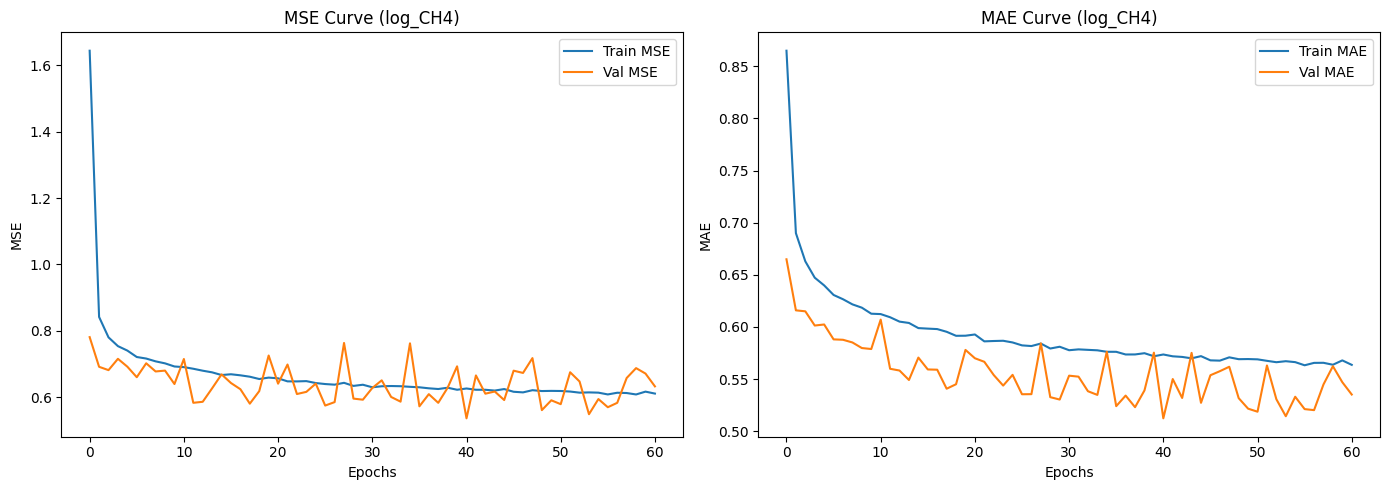

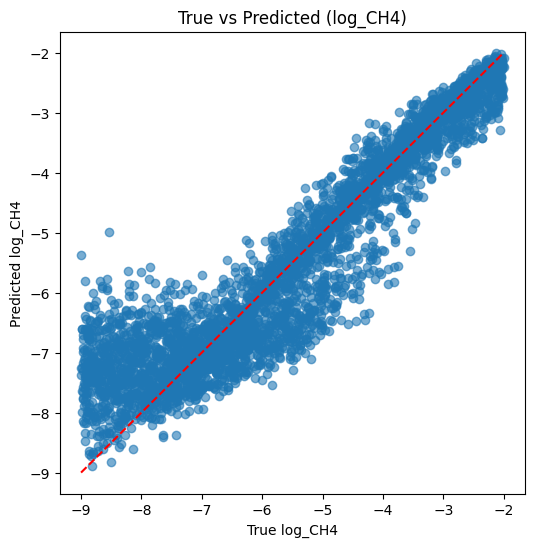

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_CH4):
Sample 1: True=-3.7520, Pred=-3.5555
Sample 2: True=-2.3250, Pred=-3.1477
Sample 3: True=-5.5602, Pred=-5.7159
Sample 4: True=-2.0579, Pred=-2.7265
Sample 5: True=-4.6979, Pred=-6.4590
Sample 6: True=-2.1599, Pred=-2.2100
Sample 7: True=-4.1700, Pred=-3.9170
Sample 8: True=-7.2142, Pred=-7.2013
Sample 9: True=-3.8872, Pred=-3.8302
Sample 10: True=-5.7000, Pred=-7.0829
Sample 11: True=-5.2123, Pred=-6.3426
Sample 12: True=-3.4811, Pred=-3.6157
Sample 13: True=-8.8888, Pred=-7.9848
Sample 14: True=-6.3782, Pred=-6.5602
Sample 15: True=-8.3330, Pred=-7.4918
Sample 16: True=-2.0433, Pred=-2.1432
Sample 17: True=-4.8368, Pred=-5.4012
Sample 18: True=-4.0518, Pred=-4.0954
Sample 19: True=-8.8686, Pred=-6.7799
Sample 20: True=-4.7812, Pred=-4.7492


# **log_NH3**

In [ ]:
target = "log_NH3"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)

In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=200, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/200, Train MSE: 1.7919, Val MSE: 0.7876, Train MAE: 0.9111, Val MAE: 0.6683
Epoch 2/200, Train MSE: 0.9368, Val MSE: 0.8279, Train MAE: 0.7297, Val MAE: 0.6749
Epoch 3/200, Train MSE: 0.8700, Val MSE: 0.7332, Train MAE: 0.7026, Val MAE: 0.6208
Epoch 4/200, Train MSE: 0.8434, Val MSE: 0.6955, Train MAE: 0.6879, Val MAE: 0.6229
Epoch 5/200, Train MSE: 0.8215, Val MSE: 0.7416, Train MAE: 0.6774, Val MAE: 0.6296
Epoch 6/200, Train MSE: 0.8154, Val MSE: 0.7159, Train MAE: 0.6732, Val MAE: 0.6307
Epoch 7/200, Train MSE: 0.8022, Val MSE: 0.7289, Train MAE: 0.6673, Val MAE: 0.6166
Epoch 8/200, Train MSE: 0.7930, Val MSE: 0.7149, Train MAE: 0.6627, Val MAE: 0.6404
Epoch 9/200, Train MSE: 0.7867, Val MSE: 0.7142, Train MAE: 0.6584, Val MAE: 0.6140
Epoch 10/200, Train MSE: 0.7756, Val MSE: 0.6711, Train MAE: 0.6551, Val MAE: 0.6055
Epoch 11/200, Train MSE: 0.7726, Val MSE: 0.6342, Train MAE: 0.6524, Val MAE: 0.5841
Epoch 12/200, Train MSE: 0.7703, Val MSE: 0.6840, Train MAE: 0.6517, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=0.784, MAE=0.571, R²=0.849


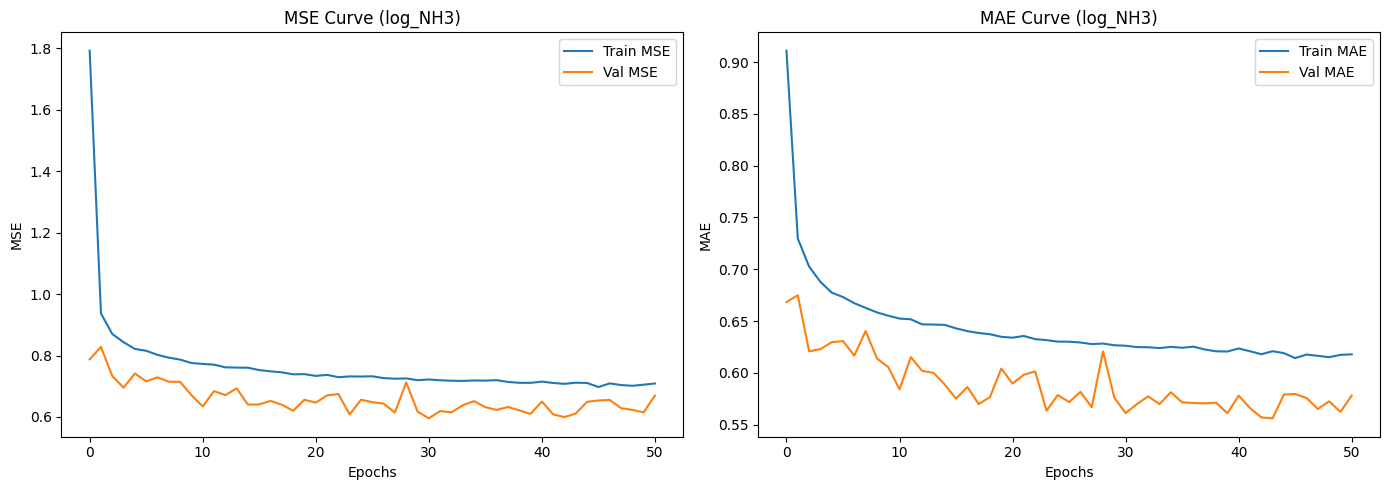

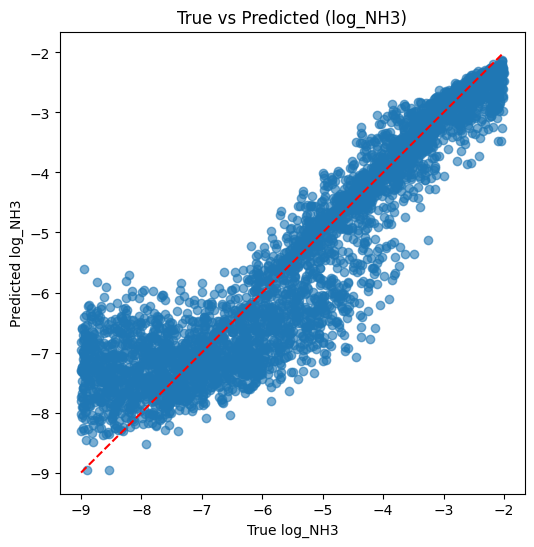

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_NH3):
Sample 1: True=-3.9342, Pred=-3.3371
Sample 2: True=-6.6135, Pred=-6.7947
Sample 3: True=-8.7241, Pred=-7.7454
Sample 4: True=-6.9910, Pred=-7.7803
Sample 5: True=-8.1256, Pred=-7.8535
Sample 6: True=-4.8334, Pred=-4.8897
Sample 7: True=-2.7690, Pred=-3.8065
Sample 8: True=-4.9253, Pred=-6.3556
Sample 9: True=-5.8259, Pred=-6.7976
Sample 10: True=-6.9105, Pred=-6.1859
Sample 11: True=-3.0558, Pred=-3.2108
Sample 12: True=-5.4624, Pred=-5.9993
Sample 13: True=-8.4189, Pred=-6.6408
Sample 14: True=-2.2952, Pred=-2.3117
Sample 15: True=-2.3851, Pred=-2.6577
Sample 16: True=-6.1568, Pred=-7.5650
Sample 17: True=-4.8091, Pred=-5.9903
Sample 18: True=-3.5148, Pred=-3.0098
Sample 19: True=-4.8933, Pred=-4.7554
Sample 20: True=-3.9679, Pred=-3.8806


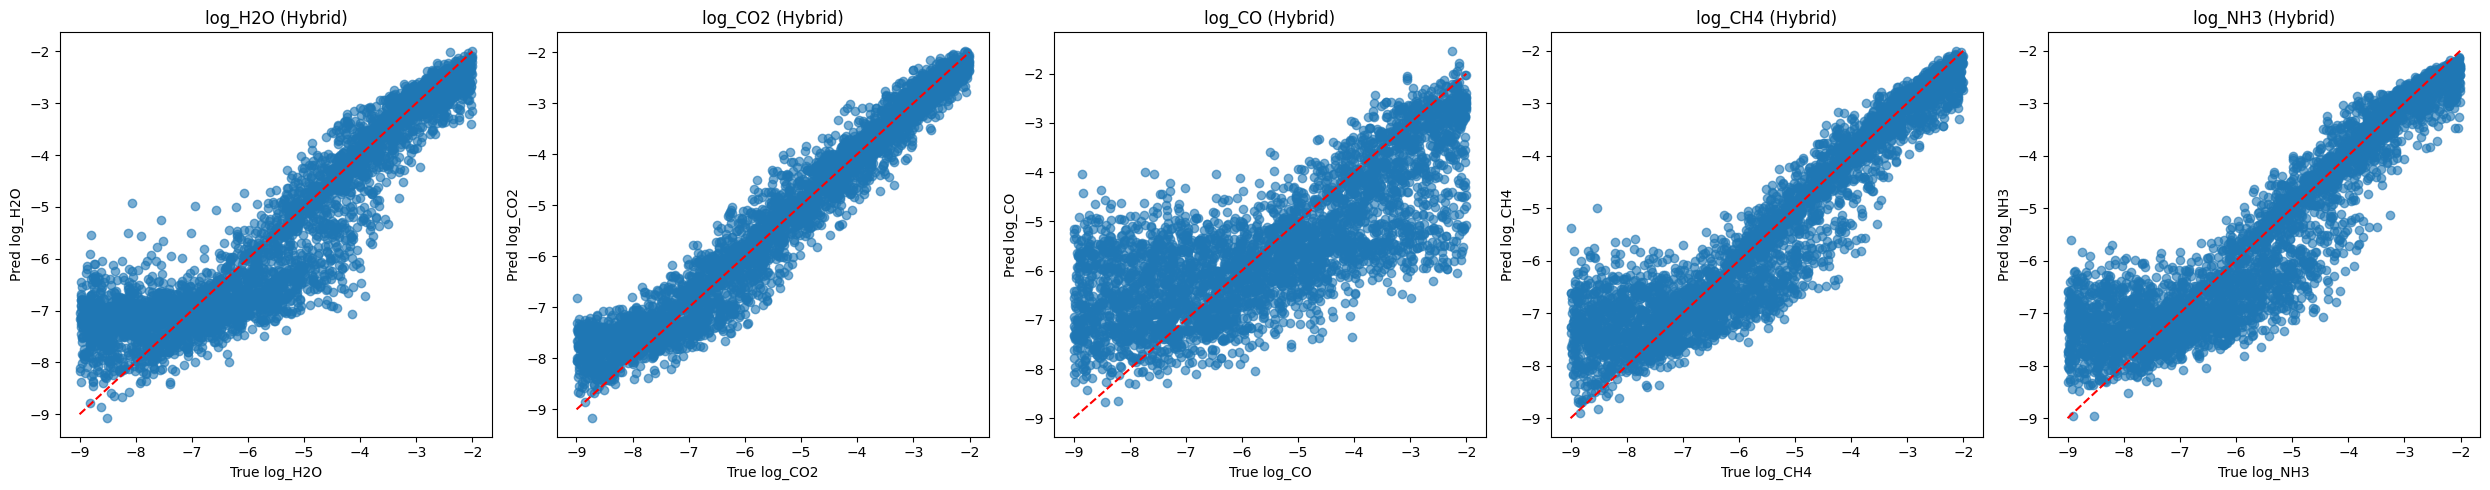

In [ ]:
targets = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

histories = {}
predictions = {}
true_values = {}

for target in targets:

    model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/abl_best_{target}.pth"))
    model.eval()

    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

    with torch.no_grad():
        y_pred = model(X_test, X_test).cpu().numpy()

    predictions[target] = y_pred
    true_values[target] = y_test.cpu().numpy()


fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 5))

if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    y_true = true_values[target]
    y_pred = predictions[target]

    ax.scatter(y_true, y_pred, alpha=0.6)
    ax.plot([y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel(f"True {target}")
    ax.set_ylabel(f"Pred {target}")
    ax.set_title(f"{target} (Hybrid)")

plt.tight_layout()
plt.show()
